# GPU V1 — Một CUDA thread xử lý một output pixel

Notebook này triển khai và đánh giá phiên bản **GPU V1** của thuật toán
**Non-Local Means (NLM)**.

GPU V1 ánh xạ mỗi CUDA thread tới một output pixel.

Mỗi thread thực hiện:

1. xác định reference patch;
2. duyệt các candidate center trong search window;
3. tính mean squared patch distance;
4. chuyển distance thành similarity weight;
5. tích lũy các candidate center pixels;
6. ghi một denoised output pixel.

## Mục tiêu

- Chạy CUDA kernel GPU V1 trên GPU local.
- So sánh GPU output với CPU reference.
- Kiểm tra pixel-wise correctness.
- So sánh PSNR và SSIM.
- Đo kernel-only runtime.
- Đo GPU end-to-end runtime.
- Tính speedup so với CPU baseline.

GPU V1 chỉ sử dụng **global memory** và chưa sử dụng **shared memory**.
Phiên bản này đóng vai trò performance baseline cho GPU V2.

## 1. Xác định project root

Notebook nằm trong thư mục `notebooks/`, trong khi source code và CUDA kernel
nằm trong các thư mục khác của project.

Cell tiếp theo sẽ:

1. tìm thư mục gốc của project;
2. kiểm tra sự tồn tại của `src`, `kernels` và `pyproject.toml`;
3. thêm project root vào `sys.path`;
4. cho phép notebook import các module từ `src.nlm`.

In [1]:
from pathlib import Path
import sys


def find_project_root() -> Path:
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (
            (path / "src").exists()
            and (path / "kernels").exists()
            and (path / "pyproject.toml").exists()
        ):
            return path

    raise FileNotFoundError(
        "Cannot locate project root."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Project root:", PROJECT_ROOT)

Project root: E:\Lap trinh song song ud\gpu_dense_vector_retrieval


## 2. Import thư viện và các module NLM

Các thành phần chính được sử dụng gồm:

- `CuPy`: quản lý GPU array, CUDA stream và CUDA Events;
- `NumPy`: xử lý dữ liệu trên CPU;
- `Matplotlib`: hiển thị ảnh và biểu đồ runtime;
- `Pandas`: tạo bảng quality metrics và benchmark;
- `NLMConfig`: quản lý cấu hình dùng chung;
- `nlm_cpu_naive`: tạo CPU reference;
- `nlm_gpu_v1`: chạy GPU V1 end-to-end;
- `create_gpu_v1_kernel_launcher`: tạo kernel launcher cho kernel-only timing;
- `compare_outputs`: kiểm tra correctness;
- `evaluate_denoising`: tính PSNR và SSIM.

In [2]:
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.nlm.benchmark import (
    benchmark_cpu_function,
    benchmark_cuda_kernel,
    benchmark_gpu_end_to_end,
)

from src.nlm.config import NLMConfig
from src.nlm.cpu import nlm_cpu_naive

from src.nlm.gpu_v1 import (
    create_gpu_v1_kernel_launcher,
    nlm_gpu_v1,
)

from src.nlm.image_utils import (
    add_gaussian_noise,
    create_camera_test_image,
)

from src.nlm.metrics import (
    compare_outputs,
    evaluate_denoising,
)

## 3. Kiểm tra môi trường CUDA

Bước này xác nhận:

- CuPy đã được cài đặt;
- CUDA runtime có thể truy cập GPU;
- GPU local được nhận diện;
- dung lượng global memory khả dụng.

Nếu cell này chạy thành công, notebook đã kết nối được với CUDA device.

In [3]:
device_count = cp.cuda.runtime.getDeviceCount()

if device_count <= 0:
    raise RuntimeError(
        "Không phát hiện CUDA GPU."
    )

device_properties = (
    cp.cuda.runtime.getDeviceProperties(0)
)

gpu_name = device_properties["name"]

if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode("utf-8")

print("CuPy version:", cp.__version__)
print("Số CUDA device:", device_count)
print("GPU:", gpu_name)

print(
    "Global memory:",
    f"{device_properties['totalGlobalMem'] / 1024**3:.2f} GB",
)

CuPy version: 14.1.1
Số CUDA device: 1
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Global memory: 4.00 GB


## 4. Cấu hình thí nghiệm

CPU reference và GPU V1 phải sử dụng cùng input và cùng tham số NLM để bảo đảm
phép so sánh correctness và runtime là công bằng.

Cấu hình hiện tại:

- Image size: `64 × 64`.
- Gaussian noise sigma: `0.08`.
- Patch size: `3 × 3`.
- Search window: `7 × 7`.
- Filtering parameter `h`: `0.12`.
- CUDA block size: `16 × 16`.
- Random seed: `42`.

Với cấu hình này:

- `patch_radius = 1`;
- `search_radius = 3`;
- `padding_radius = 4`;
- mỗi CUDA block có `256 threads`.

In [4]:
config = NLMConfig(
    image_size=64,
    noise_sigma=0.08,
    patch_size=3,
    search_window_size=7,
    h=0.12,
    random_seed=42,
    block_size_x=16,
    block_size_y=16,
)

config.validate()

print("Cấu hình NLM:")
print(config)

print(
    f"\nPatch radius: {config.patch_radius}"
)

print(
    f"Search radius: {config.search_radius}"
)

print(
    f"Padding radius: {config.padding_radius}"
)

print(
    f"CUDA block size: {config.block_size}"
)

print(
    "Số thread mỗi block:",
    config.block_size_x
    * config.block_size_y,
)

Cấu hình NLM:
NLMConfig(image_size=64, noise_sigma=0.08, patch_size=3, search_window_size=7, h=0.12, random_seed=42, block_size_x=16, block_size_y=16)

Patch radius: 1
Search radius: 3
Padding radius: 4
CUDA block size: (16, 16)
Số thread mỗi block: 256


## 5. Chuẩn bị dữ liệu thử nghiệm

Hai ảnh được tạo:

1. `clean_image`: ảnh grayscale sạch dùng làm ground truth;
2. `noisy_image`: ảnh sạch sau khi thêm Gaussian noise.

Random seed được cố định để CPU reference và GPU V1 sử dụng đúng cùng một noise pattern.
Điều này giúp phép so sánh pixel-wise có ý nghĩa.

In [5]:
clean_image = create_camera_test_image(
    image_size=config.image_size
)

noisy_image = add_gaussian_noise(
    image=clean_image,
    sigma=config.noise_sigma,
    seed=config.random_seed,
)

print(
    "Clean image:",
    clean_image.shape,
    clean_image.dtype,
    f"range=[{clean_image.min():.4f}, {clean_image.max():.4f}]",
)

print(
    "Noisy image:",
    noisy_image.shape,
    noisy_image.dtype,
    f"range=[{noisy_image.min():.4f}, {noisy_image.max():.4f}]",
)

Clean image: (64, 64) float32 range=[0.0150, 0.9191]
Noisy image: (64, 64) float32 range=[0.0000, 1.0000]


## 6. Tạo CPU reference

CPU reference được chạy trước GPU V1.

Kết quả `denoised_cpu` không chỉ dùng để hiển thị ảnh mà còn đóng vai trò
ground truth về mặt implementation.

GPU V1 được xem là correct khi output của nó gần bằng CPU reference trong
floating-point tolerance đã chọn.

In [6]:
denoised_cpu = nlm_cpu_naive(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
)

In [7]:
print(
    "CPU reference:",
    denoised_cpu.shape,
    denoised_cpu.dtype,
)

CPU reference: (64, 64) float32


## 7. Warm-up và chạy GPU V1

Lần gọi đầu tiên được sử dụng để warm-up.

Warm-up giúp loại bỏ ảnh hưởng của:

- khởi tạo CUDA context;
- compile `RawKernel` bằng NVRTC;
- khởi tạo CuPy memory pool;
- GPU clock ramp-up.

Sau warm-up, GPU V1 được chạy lại để tạo output chính thức dùng cho correctness
và quality evaluation.

In [8]:
# Warm-up: kết quả không được sử dụng.
_ = nlm_gpu_v1(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

# Chạy GPU V1 để lấy output chính thức.
denoised_gpu_v1 = nlm_gpu_v1(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

print(
    "GPU V1 output:",
    denoised_gpu_v1.shape,
    denoised_gpu_v1.dtype,
)

GPU V1 output: (64, 64) float32


## 8. Kiểm tra CPU–GPU correctness

GPU V1 phải giữ nguyên logic NLM của CPU reference.

Hai output được so sánh theo từng pixel bằng:

- absolute tolerance: `1e-5`;
- relative tolerance: `1e-5`.

Một số sai khác rất nhỏ có thể xuất hiện do thứ tự floating-point operations
trên CPU và GPU khác nhau.

Kết quả mong đợi:

```text
allclose = True
max_absolute_error <= 1e-5

In [9]:
gpu_v1_correctness = compare_outputs(
    reference=denoised_cpu,
    candidate=denoised_gpu_v1,
    atol=1e-5,
    rtol=1e-5,
)

display(gpu_v1_correctness)

assert gpu_v1_correctness["allclose"], (
    "GPU V1 không khớp với CPU reference."
)

print("CPU–GPU correctness: PASSED")

{'max_absolute_error': 5.364418029785156e-07,
 'mean_absolute_error': 6.034497346263379e-08,
 'rmse': 8.93803604841094e-08,
 'allclose': True}

CPU–GPU correctness: PASSED


## 9. Đánh giá chất lượng khử nhiễu

CPU reference và GPU V1 được đánh giá trên cùng một ảnh sạch.

Các quality metrics chính:

- **PSNR**: càng cao thì ảnh khử nhiễu càng gần ảnh sạch;
- **SSIM**: càng gần `1` thì cấu trúc ảnh được bảo toàn càng tốt.

Vì GPU V1 giữ nguyên thuật toán NLM, PSNR và SSIM của GPU V1 phải gần như giống
CPU reference.

In [10]:
cpu_quality = evaluate_denoising(
    clean=clean_image,
    noisy=noisy_image,
    denoised=denoised_cpu,
)

gpu_v1_quality = evaluate_denoising(
    clean=clean_image,
    noisy=noisy_image,
    denoised=denoised_gpu_v1,
)

quality_table = pd.DataFrame(
    [
        {
            "Implementation": "CPU reference",
            **cpu_quality,
        },
        {
            "Implementation": "GPU V1",
            **gpu_v1_quality,
        },
    ]
)

display(quality_table)

,Implementation,noisy_psnr,denoised_psnr,denoised_ssim,psnr_improvement
0,CPU reference,22.218338,29.53202,0.838319,7.313682
1,GPU V1,22.218338,29.53202,0.838319,7.313682


## 10. Hiển thị kết quả khử nhiễu

Bốn ảnh được đặt cạnh nhau:

- **Ảnh sạch**: ground truth;
- **Ảnh có noise**: input của thuật toán;
- **CPU NLM**: CPU reference;
- **GPU V1**: output của CUDA kernel.

CPU NLM và GPU V1 cần có kết quả trực quan gần như giống nhau.

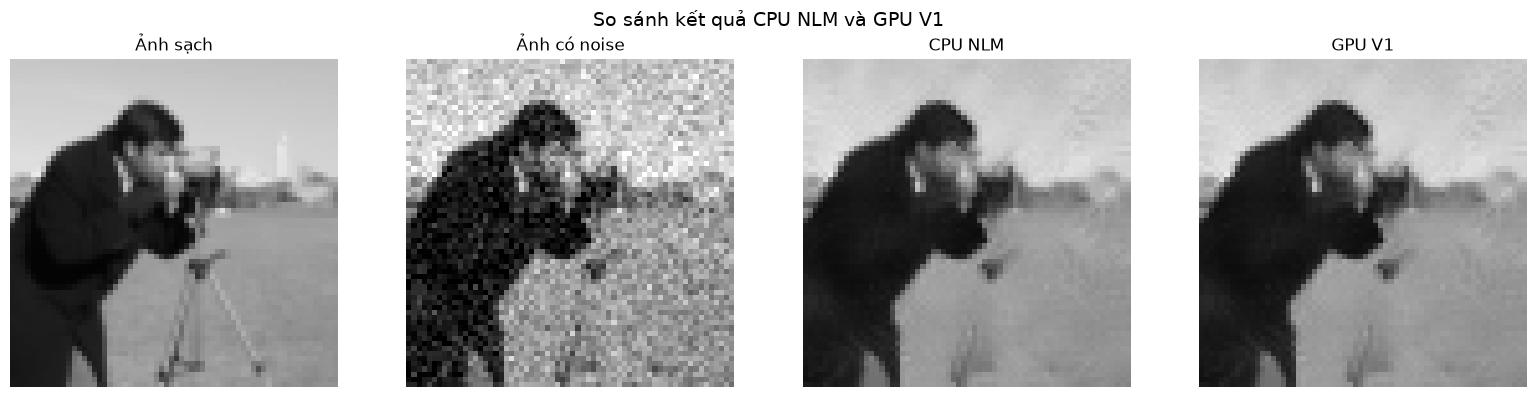

In [11]:
plt.figure(figsize=(16, 4))

images = [
    ("Ảnh sạch", clean_image),
    ("Ảnh có noise", noisy_image),
    ("CPU NLM", denoised_cpu),
    ("GPU V1", denoised_gpu_v1),
]

for index, (title, image) in enumerate(
    images,
    start=1,
):
    plt.subplot(1, 4, index)

    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    plt.title(title)
    plt.axis("off")

plt.suptitle(
    "So sánh kết quả CPU NLM và GPU V1",
    fontsize=14,
)

plt.tight_layout()
plt.show()

## 11. Benchmark CPU reference

CPU runtime được đo bằng `time.perf_counter()`.

Thiết lập benchmark:

- Warm-up runs: `0`;
- Measured runs: `3`;
- Runtime chính được báo cáo bằng median.

CPU reference là phiên bản Python naive, vì vậy kết quả speedup chỉ thể hiện mức cải thiện
so với implementation này, không đại diện cho tất cả CPU NLM implementations đã tối ưu.

In [12]:
cpu_benchmark = benchmark_cpu_function(
    function=lambda: nlm_cpu_naive(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=(
            config.search_window_size
        ),
        h=config.h,
    ),
    warmup_runs=0,
    measured_runs=3,
)

cpu_benchmark

{'times_seconds': array([1.7857833, 1.8077639, 1.7795858]),
 'median_seconds': 1.7857833000016399,
 'mean_seconds': 1.791044333333654,
 'std_seconds': 0.012090221492536956,
 'min_seconds': 1.7795858000026783,
 'max_seconds': 1.8077638999966439}

## 12. Benchmark GPU V1 end-to-end

End-to-end runtime đo toàn bộ khoảng thời gian người dùng phải chờ.

Phạm vi có thể bao gồm:

- CPU reflect padding;
- Host-to-Device transfer;
- GPU memory allocation;
- CUDA kernel execution;
- CUDA synchronization;
- Device-to-Host transfer;
- chuyển output thành NumPy array.

Thiết lập benchmark:

- Warm-up runs: `2`;
- Measured runs: `20`;
- Runtime chính được báo cáo bằng median.

In [13]:
gpu_v1_end_to_end_benchmark = (
    benchmark_gpu_end_to_end(
        function=lambda: nlm_gpu_v1(
            image=noisy_image,
            patch_size=config.patch_size,
            search_window_size=(
                config.search_window_size
            ),
            h=config.h,
            block_size=config.block_size,
        ),
        warmup_runs=2,
        measured_runs=20,
    )
)

gpu_v1_end_to_end_benchmark

{'times_seconds': array([0.0004941, 0.0004909, 0.0004864, 0.0004729, 0.000483 , 0.0002586,
        0.0002594, 0.0002519, 0.0002421, 0.0002789, 0.0002771, 0.0002847,
        0.0002784, 0.0002674, 0.0003976, 0.0004683, 0.000476 , 0.0004705,
        0.0006261, 0.0007036]),
 'median_seconds': 0.00043295000068610534,
 'mean_seconds': 0.00039839500095695257,
 'std_seconds': 0.00013369871093016122,
 'min_seconds': 0.0002420999953756109,
 'max_seconds': 0.0007036000024527311}

## 13. Benchmark GPU V1 kernel-only

Kernel-only runtime chỉ đo thời gian thực thi CUDA kernel.

Các phần sau được chuẩn bị trước và không nằm trong thời gian đo:

- reflect padding;
- Host-to-Device transfer;
- GPU memory allocation;
- Device-to-Host transfer.

CUDA Events được sử dụng thay cho CPU timer vì CUDA kernel chạy bất đồng bộ.

Thiết lập benchmark:

- Warm-up runs: `3`;
- Measured runs: `50`;
- Đơn vị đo gốc: millisecond.

In [14]:
(
    gpu_v1_kernel_launcher,
    gpu_v1_output_device,
) = create_gpu_v1_kernel_launcher(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

gpu_v1_kernel_benchmark = (
    benchmark_cuda_kernel(
        kernel_launcher=(
            gpu_v1_kernel_launcher
        ),
        warmup_runs=3,
        measured_runs=50,
    )
)

gpu_v1_kernel_benchmark

{'times_ms': array([0.063488, 0.048128, 0.048128, 0.074752, 0.074752, 0.047104,
        0.052224, 0.058368, 0.057344, 0.049152, 0.057344, 0.057344,
        0.062464, 0.049152, 0.05632 , 0.052224, 0.058368, 0.05632 ,
        0.058368, 0.053248, 0.050176, 0.039936, 0.052224, 0.054272,
        0.057344, 0.043008, 0.03584 , 0.03584 , 0.043008, 0.059392,
        0.060416, 0.0512  , 0.060416, 0.053248, 0.04608 , 0.044032,
        0.03584 , 0.03584 , 0.045056, 0.06656 , 0.038912, 0.037888,
        0.039936, 0.036864, 0.03584 , 0.038912, 0.038912, 0.03584 ,
        0.037888, 0.036864]),
 'median_ms': 0.04966400004923344,
 'mean_ms': 0.04964352041482925,
 'std_ms': 0.01029563665832593,
 'min_ms': 0.035840000957250595,
 'max_ms': 0.07475200295448303}

## 14. Tổng hợp runtime và speedup

Ba giá trị được so sánh:

1. **CPU reference**: toàn bộ CPU NLM;
2. **GPU V1 kernel-only**: chỉ CUDA kernel;
3. **GPU V1 end-to-end**: toàn bộ GPU pipeline.

Speedup được tính bằng:

```text
speedup = CPU median runtime / GPU median runtime

In [15]:
cpu_median_seconds = float(
    cpu_benchmark["median_seconds"]
)

gpu_kernel_median_seconds = (
    float(
        gpu_v1_kernel_benchmark[
            "median_ms"
        ]
    )
    / 1000.0
)

gpu_end_to_end_median_seconds = float(
    gpu_v1_end_to_end_benchmark[
        "median_seconds"
    ]
)

gpu_kernel_speedup = (
    cpu_median_seconds
    / gpu_kernel_median_seconds
)

gpu_end_to_end_speedup = (
    cpu_median_seconds
    / gpu_end_to_end_median_seconds
)

runtime_table = pd.DataFrame(
    [
        {
            "Implementation": "CPU reference",
            "Scope": "Full CPU NLM",
            "Median runtime (s)": (
                cpu_median_seconds
            ),
            "Speedup": 1.0,
        },
        {
            "Implementation": "GPU V1",
            "Scope": "Kernel only",
            "Median runtime (s)": (
                gpu_kernel_median_seconds
            ),
            "Speedup": (
                gpu_kernel_speedup
            ),
        },
        {
            "Implementation": "GPU V1",
            "Scope": "End-to-end",
            "Median runtime (s)": (
                gpu_end_to_end_median_seconds
            ),
            "Speedup": (
                gpu_end_to_end_speedup
            ),
        },
    ]
)

display(runtime_table)

print(
    f"Kernel-only speedup: "
    f"{gpu_kernel_speedup:.2f}×"
)

print(
    f"End-to-end speedup: "
    f"{gpu_end_to_end_speedup:.2f}×"
)

,Implementation,Scope,Median runtime (s),Speedup
0,CPU reference,Full CPU NLM,1.785783,1.000000
1,GPU V1,Kernel only,0.000050,35957.299014
2,GPU V1,End-to-end,0.000433,4124.687140


Kernel-only speedup: 35957.30×
End-to-end speedup: 4124.69×


## 15. Biểu đồ runtime

Biểu đồ sử dụng logarithmic scale vì CPU runtime và GPU runtime chênh lệch
nhiều bậc độ lớn.

Cần lưu ý:

- cột thấp hơn thể hiện runtime tốt hơn;
- kernel-only luôn nhỏ hơn end-to-end;
- không nên so sánh trực tiếp chiều cao trên log scale như linear scale.

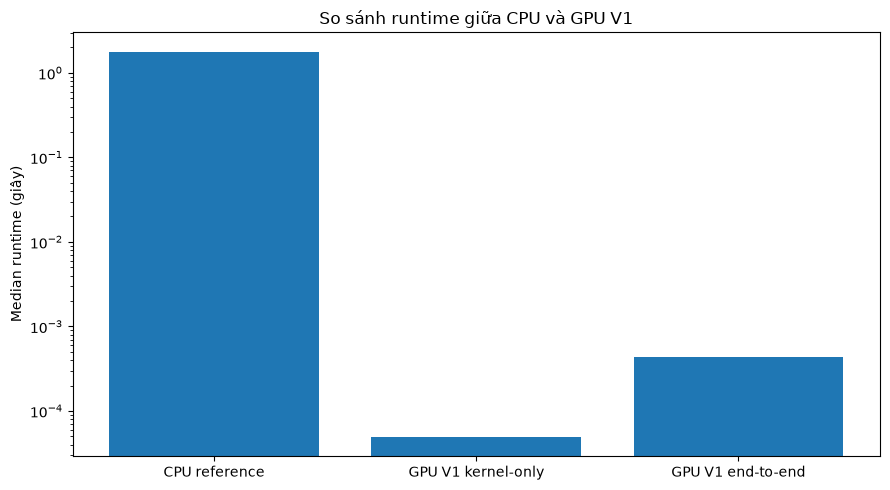

In [16]:
plt.figure(figsize=(9, 5))

plt.bar(
    [
        "CPU reference",
        "GPU V1 kernel-only",
        "GPU V1 end-to-end",
    ],
    [
        cpu_median_seconds,
        gpu_kernel_median_seconds,
        gpu_end_to_end_median_seconds,
    ],
)

plt.ylabel(
    "Median runtime (giây)"
)

plt.title(
    "So sánh runtime giữa CPU và GPU V1"
)

plt.yscale("log")
plt.tight_layout()
plt.show()

## 16. Kết luận GPU V1

GPU V1 đã ánh xạ thành công mỗi CUDA thread tới một output pixel.

Các kết quả chính:

- CUDA kernel compile và chạy thành công trên GPU local;
- GPU V1 output có cùng shape và dtype với CPU reference;
- GPU V1 đạt pixel-wise correctness trong floating-point tolerance;
- PSNR và SSIM được bảo toàn;
- kernel-only runtime thấp hơn đáng kể so với CPU runtime;
- end-to-end runtime vẫn lớn hơn kernel-only do có padding, allocation và data transfer.

### Bottleneck còn lại

GPU V1 chỉ sử dụng global memory.

Các CUDA thread lân cận liên tục đọc lại những vùng patch chồng lặp từ global memory.
Điều này tạo ra nhiều global memory accesses dư thừa.

GPU V2 sẽ giải quyết hạn chế này bằng:

- shared-memory tile;
- halo region;
- cooperative loading;
- synchronization giữa các thread trong cùng CUDA block.